In [2]:
import math
import numpy as np
import random
import time
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.patches import Ellipse
from itertools import chain
import time
from tqdm import tqdm
from operator import attrgetter
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
from scipy.stats import chi2
from scipy.spatial.distance import pdist

In [4]:
np.max([1,2,3])

np.int64(3)

In [3]:
# surface functions, merge function, and other helper functions

def surface_single(x, U, A, p=2, k=1):
    """
    Compute the hyperellipsoid surface function for a single point.

    Parameters
    ----------
    x : np.ndarray, shape (d,)
        The query point.
    U : np.ndarray, shape (d, d)
        Eigenvectors (columns) defining the ellipsoid orientation.
    A : np.ndarray, shape (d,)
        Semi-axis lengths along each eigenvector direction.
    p : float or np.ndarray, shape (d)
        power/exponent of the ellipsoid axes.
    k : float
        confidence value

    Returns
    -------
    float
        < 0 if x is inside the ellipsoid
        = 0 if x is on the surface
        > 0 if x is outside the ellipsoid
    """
    x_local = U.T @ x        # Project into ellipsoid's local frame, shape (d,)
    return np.sum(np.abs(x_local / A) ** p) - (k ** 2)

def surface_multi(xs, Us, As, p=2, k=1):
    """
    Compute the hyperellipsoid surface function for n points,
    each against its own ellipsoid.

    Parameters
    ----------
    xs : np.ndarray, shape (n, d)
        Query points.
    Us : np.ndarray, shape (n, d, d)
        Per-ellipsoid eigenvector matrices.
    As : np.ndarray, shape (n, d)
        Per-ellipsoid semi-axis lengths.

    Returns
    -------
    np.ndarray, shape (n,)
        Surface function value for each (point, ellipsoid) pair.
        < 0 inside, = 0 on surface, > 0 outside.
    """
    xs_local = np.einsum('ndi, ni -> nd', Us.swapaxes(1,2), xs)  # (n, d)
    return np.sum(np.abs(xs_local / As) ** p, axis=1) - (k ** 2)              # (n,)

def merge_nodes(x, y): # NOTE: New P is currently avg of the 2 that is (x.p + y.p) / 2
    new_n = x.n + y.n
    dist = x.M - y.M
    new_M = ((x.n * x.M) + (y.n * y.M)) / (new_n)
    new_S = ((x.n / new_n) * x.S) + ((y.n / new_n) * y.S) + (((x.n * y.n)/ (new_n ** 2)) * (np.outer(dist, dist)))
    eigen_value, eigen_vector = np.linalg.eigh(new_S)
    # reverse the order of the eigenvalue/vectors to be in DESCENDING order
    eigen_value = eigen_value[::-1]
    eigen_vector = eigen_vector[:, ::-1]
    # eigen_vector = eigen_vector.T
    # calculate new width that based on confidence ellipsoid
    confidence = new_n / (new_n + x.dim)
    chi = chi2.ppf(confidence, x.dim)
    new_A = np.sqrt(np.abs(eigen_value) * chi)
    new_A[new_A == 0] = x.eps

    return Node(dimension=x.dim, label=x.label, A=new_A, n=new_n, M=new_M, S=new_S, U=eigen_vector, eps=x.eps, alpha=x.alpha, p=(x.p + y.p) / 2)

def print_stat(arr, name):
    print(f"{name} Mean:", np.mean(arr))
    print(f"{name} Max:", np.max(arr))
    print(f"{name} Min:", np.min(arr))

def print_time(arr, name):
    print(f"action: {name}")
    print(f"count: {len(arr)}")
    print(f"total: {sum(arr)}")
    print(f"avg: {sum(arr)/len(arr)}")

def train_test_split(ds, test_ratio=0.2):
    ds = ds[:]  # copy
    random.shuffle(ds)

    split_idx = int(len(ds) * (1 - test_ratio))
    return ds[:split_idx], ds[split_idx:]



In [27]:
def uniform_points(c, A, U, P, n=10_000):
    a_max = np.max(A)
    points = np.random.uniform(low=c - a_max, high=c + a_max, size=(n,)+A.shape)
    points = np.linalg.solve(U, points.T).T
    return points

In [28]:
c = np.array([5, 5])
v1 = np.array([1, 1])
v2 = np.array([-1, 1])
u1 = v1 / np.linalg.norm(v1)
u2 = v2 / np.linalg.norm(v2)
U = np.array([u1, u2])
A = np.array([4, 1])
P = np.array([2, 2])

points = uniform_points(c, A, U, P)

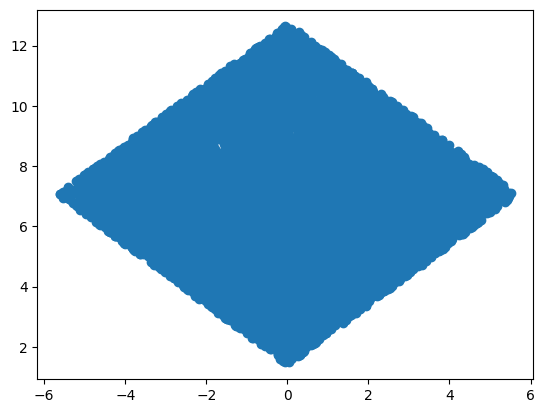

In [29]:
plt.scatter(points[:, 0], points[:, 1])

In [30]:
c = np.array([5, 5])
u1 = np.array([1, 0])
u2 = np.array([0, 1])
U = np.array([u1, u2])
A = np.array([4, 1])
P = np.array([2, 2])

points = uniform_points(c, A, U, P)

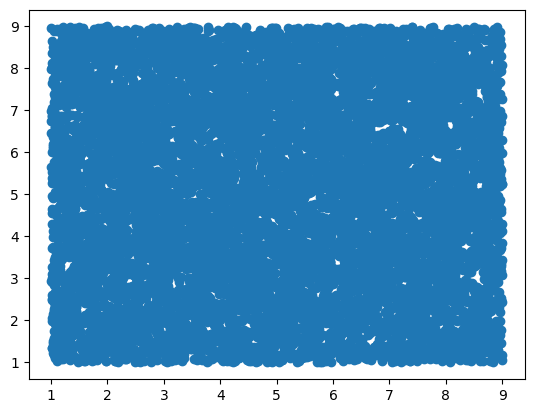

In [31]:
plt.scatter(points[:, 0], points[:, 1])